In [3]:
from eib import *

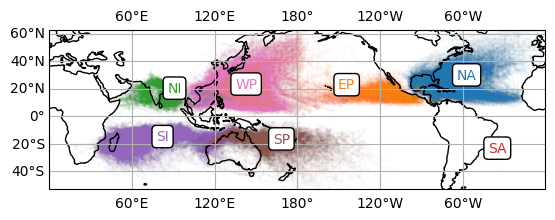

In [4]:
ax = plt.axes(projection = ccrs.PlateCarree(central_longitude = 180))
ax.coastlines()
ax.gridlines(draw_labels=True)
ax.set_extent([50,359,-50,60])
pal = sns.color_palette("tab10")
for i, b in enumerate(BASINS):
    # Load the entire ibtracs dataset
    with open("../ibtracs/ibtracs_"+b+".pkl", "rb") as f:
        ib = pkl.load(f)[["lon", "lat"]].to_dataframe()
    ax.scatter(ib.lon, ib.lat, transform = ccrs.PlateCarree(), 
               alpha = 0.05, s = 0.1, c = [pal[i]])
    L = np.where(ib.lon < 0, ib.lon+360, ib.lon)
    ax.text(L.mean(), ib.lat.mean(), b, transform=ccrs.PlateCarree(), 
            c = pal[i],
           bbox=dict(facecolor='w', edgecolor='black', boxstyle='round'))
plt.savefig("ib_basins.png", bbox_inches = "tight")